# Day 3 Project: Student Performance Prediction

## Import libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Imports successful")

Imports successful


In [58]:
df = pd.read_csv("data/student-mat.csv", sep=";")

print("Shape:", df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [35]:
print("Columns:")
print(df.columns.tolist())

print("\n--- Info ---")
df.info()

print("\n--- Statistical Summary ---")
df.describe()

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  trav

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Check missing values and duplicates

In [36]:
print("Total missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


##  Explore the target (G3)

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


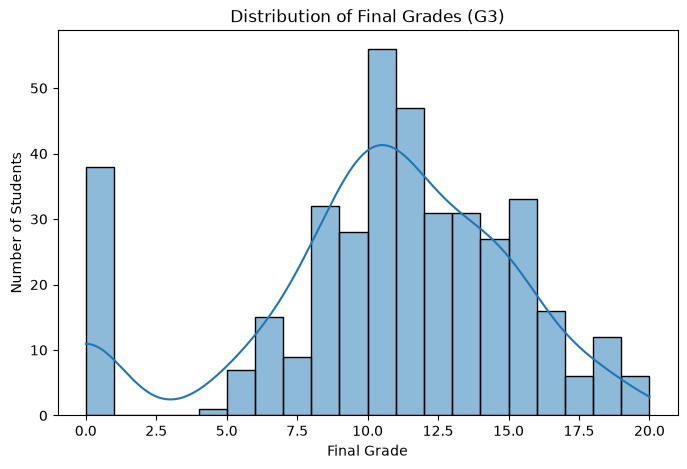

In [37]:
print(df["G3"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

## Select features and target

In [38]:
features = [
    "school",
    "sex",
    "age",
    "studytime",
    "failures",
    "schoolsup",
    "famsup",
    "internet",
    "absences",
    "G1",
    "G2"
]

numerical_features = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]

categorical_features = [
    "school",
    "sex",
    "schoolsup",
    "famsup",
    "internet"
]

X = df[features]
y = df["G3"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (395, 11)
y shape: (395,)


,school,sex,age,studytime,failures,schoolsup,famsup,internet,absences,G1,G2
0,GP,F,18,2,0,yes,no,no,6,5,6
1,GP,F,17,2,0,no,yes,yes,4,5,5
2,GP,F,15,2,3,yes,no,yes,10,7,8
3,GP,F,15,3,0,no,yes,yes,2,15,14
4,GP,F,16,2,0,no,yes,no,4,6,10


##  Train/test split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 316
Testing samples: 79


## Build the preprocessing pipeline

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created")

Preprocessor created


## Build the regression pipeline

In [41]:
regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Regression pipeline created")

Regression pipeline created


## Train the regression model

In [42]:
regression_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## Make predictions

In [43]:
y_pred = regression_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,10,6.919296
1,12,12.323387
2,5,3.233113
3,10,8.029445
4,9,8.141176
5,13,12.589400
6,18,19.208599
7,6,7.383780
8,0,6.671952
9,14,13.183726


## Regression metrics (MAE, MSE, RMSE, R²)

In [44]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.4188
MSE  : 4.6417
RMSE : 2.1545
R²   : 0.7736


## Overfitting check

In [45]:
train_pred = regression_model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, y_pred)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Training MAE : {train_mae:.4f}")
print(f"Testing MAE  : {test_mae:.4f}")
print(f"Training R²  : {train_r2:.4f}")
print(f"Testing R²   : {test_r2:.4f}")

Training MAE : 1.1569
Testing MAE  : 1.4188
Training R²  : 0.8443
Testing R²   : 0.7736


## Actual vs Predicted plot

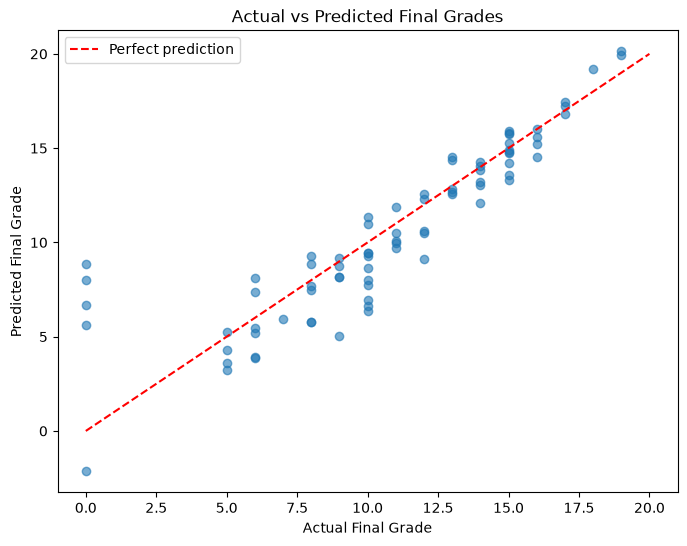

In [46]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], "r--", label="Perfect prediction")
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grades")
plt.legend()
plt.show()

## Create the Pass/Fail label

In [47]:
df["pass"] = (df["G3"] >= 10).astype(int)

print(df["pass"].value_counts())
print(f"\nPass rate: {df['pass'].mean():.2%}")

pass
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.09%


##  Classification split (stratified)

In [48]:
X_class = df[features]
y_class = df["pass"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training samples:", len(X_train_class))
print("Testing samples :", len(X_test_class))
print("Train pass rate :", f"{y_train_class.mean():.2%}")
print("Test pass rate  :", f"{y_test_class.mean():.2%}")

Training samples: 316
Testing samples : 79
Train pass rate : 67.09%
Test pass rate  : 67.09%


##  Build classification pipeline

In [49]:
classification_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

print("Classification pipeline created")

Classification pipeline created


## Train the classification model


In [50]:
classification_model.fit(X_train_class, y_train_class)

print("Classification model trained successfully")

Classification model trained successfully


## Make classification predictions

In [51]:
y_class_pred = classification_model.predict(X_test_class)

print("First 20 predictions:", y_class_pred[:20])

First 20 predictions: [1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0]


## Classification metrics

In [52]:
accuracy = accuracy_score(y_test_class, y_class_pred)
precision = precision_score(y_test_class, y_class_pred, zero_division=0)
recall = recall_score(y_test_class, y_class_pred, zero_division=0)
f1 = f1_score(y_test_class, y_class_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8861
Precision: 0.9400
Recall   : 0.8868
F1-score : 0.9126


## Classification report

In [53]:
print(classification_report(
    y_test_class,
    y_class_pred,
    target_names=["Fail", "Pass"],
    zero_division=0
))

              precision    recall  f1-score   support

        Fail       0.79      0.88      0.84        26
        Pass       0.94      0.89      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.87        79
weighted avg       0.89      0.89      0.89        79



## Confusion matrix

[[23  3]
 [ 6 47]]


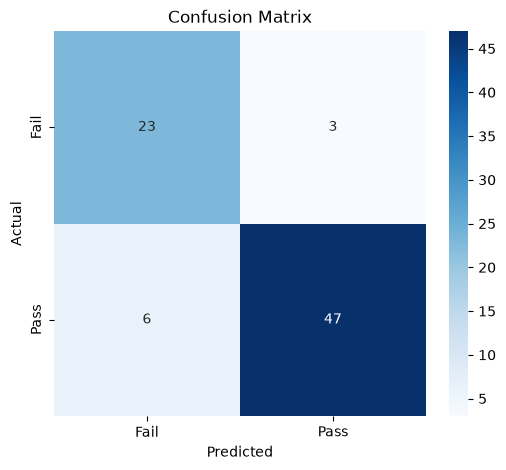

In [54]:
cm = confusion_matrix(y_test_class, y_class_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Test a custom student (regression + classification

In [56]:
new_student = pd.DataFrame({
    "school": ["GP"],
    "sex": ["M"],
    "age": [17],
    "studytime": [3],
    "failures": [0],
    "schoolsup": ["no"],
    "famsup": ["yes"],
    "internet": ["yes"],
    "absences": [4],
    "G1": [15],
    "G2": [16]
})

predicted_grade = regression_model.predict(new_student)[0]
predicted_status = classification_model.predict(new_student)[0]

print(f"Predicted final grade: {predicted_grade:.2f}")
print("Prediction:", "PASS" if predicted_status == 1 else "FAIL")

Predicted final grade: 16.18
Prediction: PASS
